##Correlation and Regression Analysis – CBAV3 and Aluminum

The purpose of this study is to evaluate the degree of linear association between the returns of CBAV3.SA (Companhia Brasileira de Alumínio, listed on the Brazilian Stock Exchange – B3) and the returns of aluminum futures (ALI=F) traded in international markets.

Beyond assessing the static and rolling (time-varying) correlations between both time series, this analysis aims to estimate a simple linear regression model to quantify the extent to which variations in aluminum prices can statistically explain the behavior of CBAV3’s stock returns.

This approach provides an empirical framework to measure the sensitivity of CBA’s equity performance to fluctuations in the underlying commodity market, offering insights into the firm’s exposure to aluminum price dynamics and the potential effectiveness of its hedging and operational strategies.

In [3]:
#Libraries
import time
import pandas as pd
import numpy as np
from pandas_datareader import data as pdr
import yfinance as yf
from matplotlib import pyplot as plt
from datetime import date, datetime, timedelta
from dateutil.relativedelta import relativedelta
import statsmodels.api as sm

#Plot Style
plt.style.use('seaborn-v0_8-darkgrid')

import warnings
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

In [4]:
# Analysis Period
end_date = date.today()
start_date = end_date - relativedelta(months = 48)  # 48 months


symbols = ['CBAV3.SA', 'ALI=F']
# Download Adjusted Close Data
df = yf.download(
    tickers = symbols,
    start = start_date,
    auto_adjust = False,
    progress = True,
)["Adj Close"]

[*********************100%***********************]  2 of 2 completed


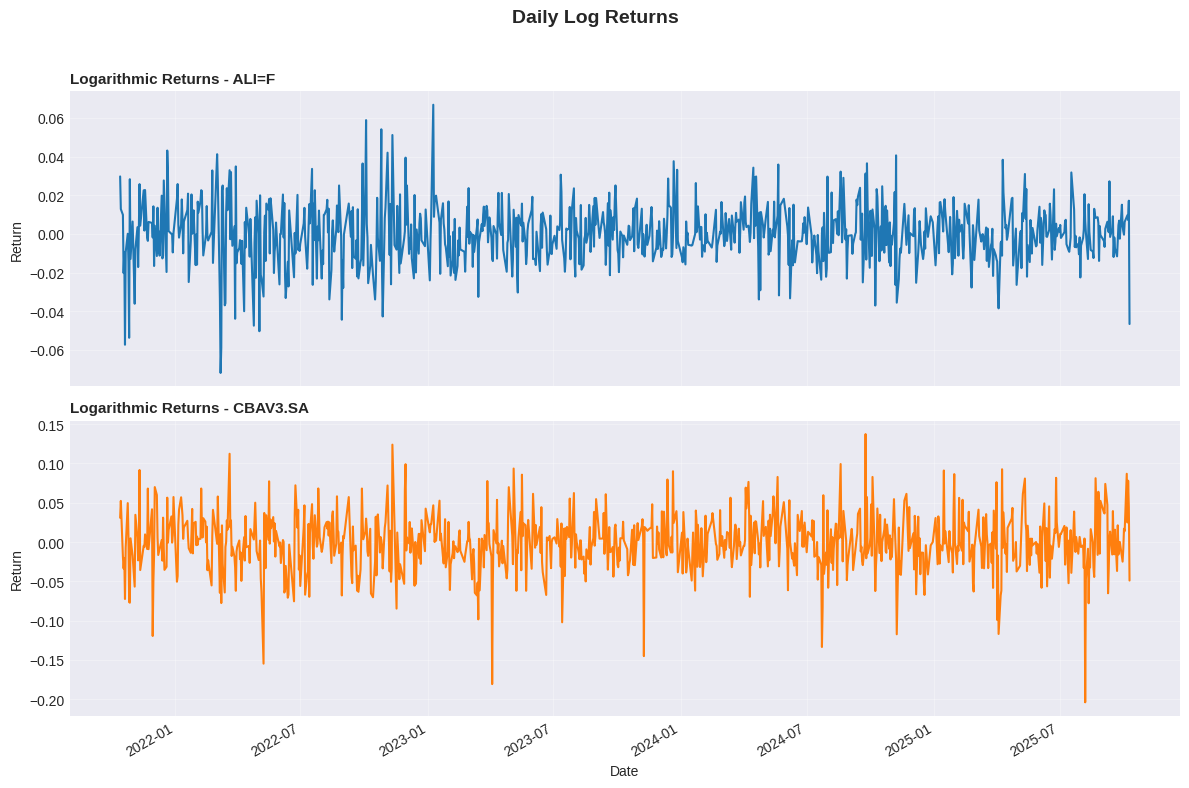

In [5]:
# Logarithmic Returns
returns = np.log(df / df.shift(1))
returns.dropna(inplace=True)

# Plotting
ax = returns.plot(
    subplots=True,
    figsize=(12, 8),
    linewidth=1.5,
    legend=False,
    sharex=True,
)

# Subplots
for a, col in zip(ax, returns.columns):
    a.set_title(f"Logarithmic Returns - {col}", fontsize=11, fontweight="bold", loc="left")
    a.set_ylabel("Return")
    a.grid(alpha=0.3)

# Layout
plt.suptitle("Daily Log Returns", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

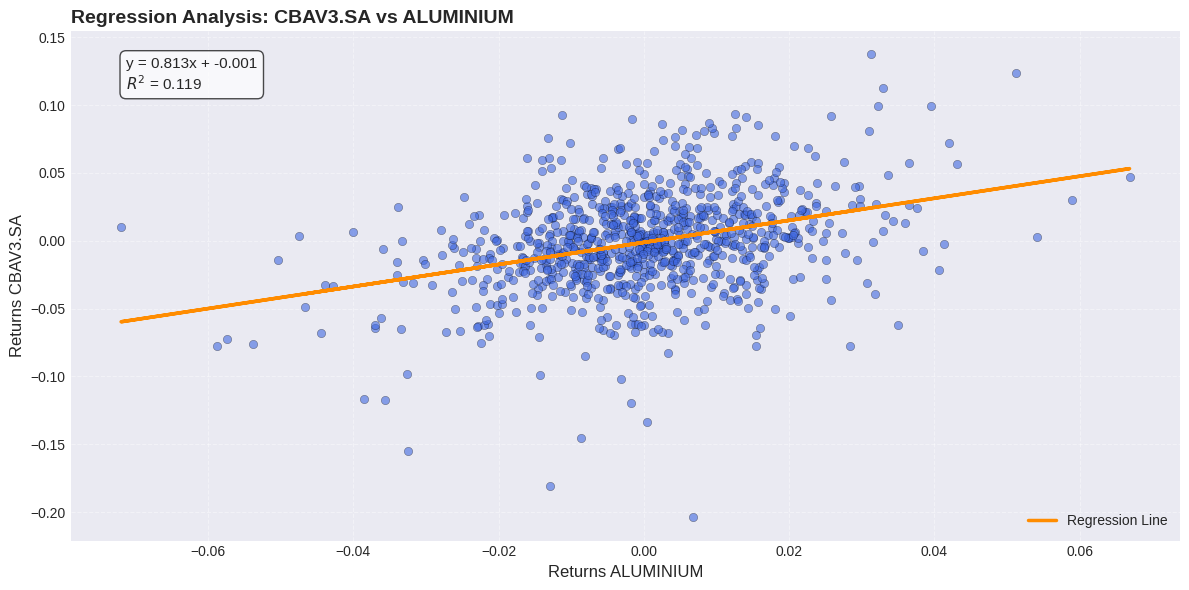

In [7]:
# Linear Regression
x = returns['ALI=F']
y = returns['CBAV3.SA']
regression = np.polyfit(x, y, deg=1)
slope, intercept = regression
r2 = np.corrcoef(x, y)[0, 1] ** 2

# Style
fig, ax = plt.subplots(figsize=(12, 6))

# Scatter Plot
ax.scatter(x, y, alpha=0.6, edgecolors='k', linewidth=0.3, color='royalblue')

# Regression Line
ax.plot(x, np.polyval(regression, x), color='darkorange', lw=2.5, label='Regression Line')

# Axis and title
ax.set_title('Regression Analysis: CBAV3.SA vs ALUMINUM', fontsize=14, fontweight='bold', loc='left')
ax.set_xlabel('Returns ALUMINUM', fontsize=12)
ax.set_ylabel('Returns CBAV3.SA', fontsize=12)

# Plot edit
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.4)

# Regression Equation and R^2
equation_text = f"y = {slope:.3f}x + {intercept:.3f}\n$R^2$ = {r2:.3f}"
ax.text(
    0.05, 0.95, equation_text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.7)
)

# Legenda
ax.legend(frameon=False, loc='lower right')

plt.tight_layout()
plt.show()


In [8]:
# OLS Regression Results

# Add constant
X = sm.add_constant(x)

# OLS model
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:               CBAV3.SA   R-squared:                       0.119
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     122.6
Date:                Sat, 11 Oct 2025   Prob (F-statistic):           8.03e-27
Time:                        19:21:17   Log-Likelihood:                 1790.0
No. Observations:                 913   AIC:                            -3576.
Df Residuals:                     911   BIC:                            -3566.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0012      0.001     -1.077      0.2

#### Regression Analysis

- R - Squared: About 10,6% of the variation in CBAV3s returns is explained by aluminum price movements. Indicates a weak but non-negligible linear relationship

- P < 000.1: The model as a whole is highly statistically significant, aluminum returns have explanatory power over CBAV3s returns.

- Intercept = -0.0014 : The average return of CBAV3 when aluminum returns are zero is slightly negative but statistically insignificant (p > 0.05). This means there is no strong evidence of a systematic drift.

- Slope = 0.8542: The coefficient is positive and highly significant (t = 9.013, p < 0.001). It implies that, on average, a 1% increase in aluminum returns is associated with a 0.85% increase in CBAV3 returns.

- Durbin - Watson = 1.96: No autocorrelation in residuals.

#### Model Evaluation
- Statistically significant relationship between aluminum and CBAV3 returns.
- Low explanatory power (R^2 = 0.106): aluminum is only one of several drivers of CBAV3s performance (others likely include FX rate, production costs, energy prices, and macroeconomic conditions).
- Positive and economically intuitive slope: confirms that CBAV3, as an aluminum producer, tends to benefit from increases in aluminum prices.

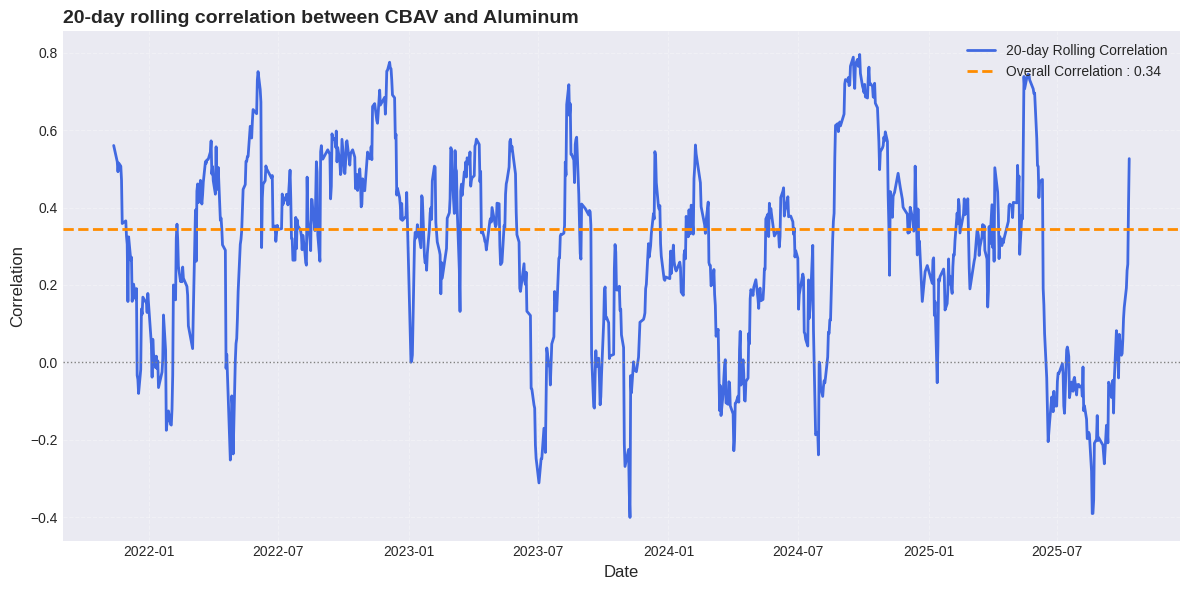

In [11]:
# Rolling Correlation
rolling_corr = returns['ALI=F'].rolling(window=20).corr(returns['CBAV3.SA'])
corr_global = returns['ALI=F'].corr(returns['CBAV3.SA'])

#Style
fig, ax = plt.subplots(figsize=(12, 6))

#Plot
ax.plot(
    rolling_corr.index, rolling_corr,
    color='royalblue',
    linewidth=2,
    label='20-day Rolling Correlation'
)

# Global Correlation
ax.axhline(corr_global, color='darkorange', linewidth=2, linestyle='--', label=f'Overall Correlation : {corr_global:.2f}')

# Line at zero point
ax.axhline(0, color='gray', linewidth=1, linestyle=':')

# Title and Axis
ax.set_title('20-day rolling correlation between CBAV and Aluminum', fontsize=14, fontweight='bold', loc='left')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Correlation', fontsize=12)


# Legend
ax.legend(frameon = False, loc='upper right')
ax.grid(alpha = 0.3, linestyle = '--')

plt.tight_layout()
plt.show()

### Conclusion

The 20-day rolling correlation shows that the relationship between CBAV3’s stock returns and aluminum prices is **positive but highly variable over time**. While the average correlation remains moderate (≈ 0.34), the short-term dynamics fluctuate between negative and strongly positive values, indicating that **CBA’s sensitivity to aluminum prices is not constant**. These variations reflect changes in **market conditions, hedging strategies, and macroeconomic factors**, emphasizing the importance of using rolling correlations to capture the firm’s evolving exposure to commodity price movements.
